# Getting Started: Comparing VQE, VarQITE, and QPE on H2

This notebook compares the three main workflows in the repository on the same
small molecule: **H2**.

Goals:

- run a minimal **VQE** calculation
- run a minimal **VarQITE** calculation
- run a minimal **QPE** calculation
- compare their final energy estimates against the exact spectrum

This is a compact comparison notebook rather than a benchmarking notebook.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import get_exact_spectrum
from qite.core import run_qite
from qpe.core import run_qpe
from vqe.core import run_vqe

## Exact reference spectrum

For `H2`, we can compute the exact spectrum and use it as a common reference
for all three methods.

In [2]:
exact_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])

print("Exact spectrum:")
print(exact_spectrum)
print()
print(f"Exact ground-state energy: {exact_ground_energy:.10f}")

Exact spectrum:
[-1.13727017 -0.53870958 -0.53870958 -0.53247901 -0.53247901 -0.53247901
 -0.44698573 -0.44698573 -0.1699014   0.23780527]

Exact ground-state energy: -1.1372701749


## Small helper utilities

The three workflows return different result dictionaries, so we use a few
small helpers to keep the notebook compact.

In [3]:
def as_1d_float_array(x):
    if x is None:
        return None
    arr = np.asarray(x, dtype=float)
    return arr.ravel()


def qpe_energy_estimate(res: dict):
    if "energy" in res:
        return float(res["energy"])
    if "best_energy" in res:
        return float(res["best_energy"])
    return None

## Run VQE

We start with a small VQE calculation using a standard ansatz and optimizer.

In [4]:
vqe_res = run_vqe(
    molecule="H2",
    ansatz_name="UCCSD",
    optimizer_name="Adam",
    steps=50,
    stepsize=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

Step 01/50: E = -1.116684 Ha
Step 02/50: E = -1.136994 Ha
Step 03/50: E = -1.131007 Ha
Step 04/50: E = -1.122700 Ha
Step 05/50: E = -1.130115 Ha


Step 06/50: E = -1.133031 Ha
Step 07/50: E = -1.134496 Ha
Step 08/50: E = -1.134652 Ha
Step 09/50: E = -1.132102 Ha
Step 10/50: E = -1.130839 Ha
Step 11/50: E = -1.133769 Ha
Step 12/50: E = -1.136856 Ha
Step 13/50: E = -1.136817 Ha
Step 14/50: E = -1.134837 Ha
Step 15/50: E = -1.133732 Ha
Step 16/50: E = -1.134458 Ha
Step 17/50: E = -1.135957 Ha
Step 18/50: E = -1.136742 Ha
Step 19/50: E = -1.136508 Ha
Step 20/50: E = -1.136055 Ha
Step 21/50: E = -1.135899 Ha
Step 22/50: E = -1.135938 Ha
Step 23/50: E = -1.136174 Ha
Step 24/50: E = -1.136688 Ha
Step 25/50: E = -1.137068 Ha
Step 26/50: E = -1.136886 Ha
Step 27/50: E = -1.136406 Ha
Step 28/50: E = -1.136270 Ha
Step 29/50: E = -1.136684 Ha
Step 30/50: E = -1.137181 Ha
Step 31/50: E = -1.137213 Ha
Step 32/50: E = -1.136850 Ha
Step 33/50: E = -1.136654 Ha
Step 34/50: E = -1.136858 Ha
Step 35/50: E = -1.137135 Ha
Step 36/50: E = -1.137184 Ha
Step 37/50: E = -1.137075 Ha
Step 38/50: E = -1.137000 Ha
Step 39/50: E = -1.137018 Ha
Step 40/50: E 

In [5]:
vqe_energies = as_1d_float_array(vqe_res["energies"])
vqe_final_energy = float(vqe_res["energy"])

print(f"VQE final energy: {vqe_final_energy:.10f}")

VQE final energy: -1.1371763799


## Run VarQITE

Next we run a small imaginary-time calculation on the same molecule.

In [6]:
qite_res = run_qite(
    molecule="H2",
    ansatz_name="UCCSD",
    steps=50,
    dtau=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)


⚙️ Using VarQITE (McLachlan) update rule


Iter 01/50: E = 0.919499 Ha
Iter 02/50: E = 0.919090 Ha
Iter 03/50: E = 0.918400 Ha
Iter 04/50: E = 0.917228 Ha
Iter 05/50: E = 0.915231 Ha
Iter 06/50: E = 0.911812 Ha
Iter 07/50: E = 0.905932 Ha
Iter 08/50: E = 0.895790 Ha
Iter 09/50: E = 0.878285 Ha
Iter 10/50: E = 0.848193 Ha
Iter 11/50: E = 0.797081 Ha
Iter 12/50: E = 0.712464 Ha
Iter 13/50: E = 0.578888 Ha
Iter 14/50: E = 0.384549 Ha
Iter 15/50: E = 0.136348 Ha
Iter 16/50: E = -0.126801 Ha
Iter 17/50: E = -0.352718 Ha
Iter 18/50: E = -0.520319 Ha
Iter 19/50: E = -0.643764 Ha
Iter 20/50: E = -0.742080 Ha
Iter 21/50: E = -0.824699 Ha
Iter 22/50: E = -0.893739 Ha
Iter 23/50: E = -0.949299 Ha
Iter 24/50: E = -0.992554 Ha
Iter 25/50: E = -1.025747 Ha
Iter 26/50: E = -1.051214 Ha
Iter 27/50: E = -1.070865 Ha
Iter 28/50: E = -1.086098 Ha
Iter 29/50: E = -1.097919 Ha
Iter 30/50: E = -1.107077 Ha
Iter 31/50: E = -1.114153 Ha
Iter 32/50: E = -1.119601 Ha
Iter 33/50: E = -1.123783 Ha
Iter 34/50: E = -1.126985 Ha
Iter 35/50: E = -1.129432 Ha


In [7]:
qite_energies = as_1d_float_array(qite_res["energies"])
qite_final_energy = float(qite_res["energy"])

print(f"VarQITE final energy: {qite_final_energy:.10f}")

VarQITE final energy: -1.1371357467


## Run QPE

Finally we run a small QPE calculation. This is a compact demonstration, so
the settings are intentionally modest.

In [37]:
qpe_res = run_qpe(
    molecule="H2",
    n_ancilla=4,
    t=1.0,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

In [38]:
qpe_final_energy = qpe_energy_estimate(qpe_res)

print(f"QPE estimated energy: {qpe_final_energy:.10f}")
print(f"QPE best bitstring: {qpe_res.get('best_bitstring')}")
print(f"QPE estimated phase: {qpe_res.get('phase')}")
print(f"QPE Hartree–Fock reference energy: {qpe_res.get('hf_energy'):.10f}")

QPE estimated energy: -1.1780972451
QPE best bitstring: 0011
QPE estimated phase: 0.1875
QPE Hartree–Fock reference energy: -1.1166843872


## Compare final energy estimates

In [39]:
rows = [
    ("VQE", vqe_final_energy),
    ("VarQITE", qite_final_energy),
    ("QPE", qpe_final_energy),
]

print(f"{'Method':<10} {'Energy':>16} {'|ΔE| vs exact':>18}")
print("-" * 46)
for name, energy in rows:
    if energy is None:
        print(f"{name:<10} {'n/a':>16} {'n/a':>18}")
    else:
        err = abs(float(energy) - exact_ground_energy)
        print(f"{name:<10} {float(energy):>16.10f} {err:>18.6e}")

Method               Energy      |ΔE| vs exact
----------------------------------------------
VQE           -1.1371763799       9.379501e-05
VarQITE       -1.1371357467       1.344282e-04
QPE           -1.1780972451       4.082707e-02


## Optimization / evolution traces

VQE and VarQITE both return an energy trajectory over iterations, so we can
compare how the two approaches move toward the ground state.

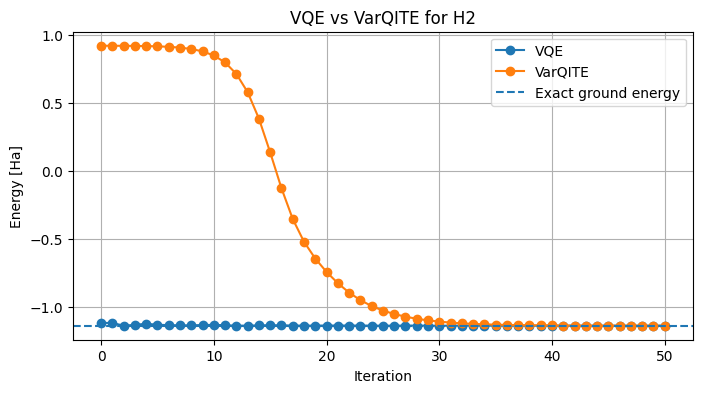

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(vqe_energies)), vqe_energies, marker="o", label="VQE")
plt.plot(np.arange(len(qite_energies)), qite_energies, marker="o", label="VarQITE")
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VQE vs VarQITE for H2")
plt.grid(True)
plt.legend()
plt.show()

## QPE returned distribution

When available, the QPE distribution is worth inspecting directly.

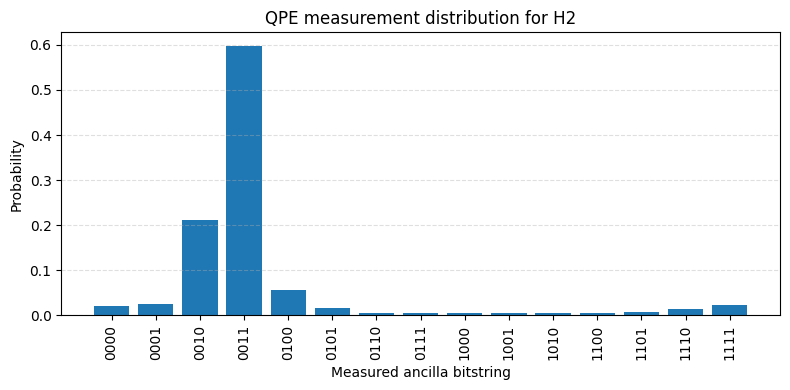

In [40]:
qpe_counts = qpe_res.get("counts", {})
qpe_probs = qpe_res.get("probs", {})

if qpe_probs:
    bitstrings = sorted(qpe_probs.keys())
    probabilities = [float(qpe_probs[b]) for b in bitstrings]

    plt.figure(figsize=(8, 4))
    plt.bar(bitstrings, probabilities)
    plt.xlabel("Measured ancilla bitstring")
    plt.ylabel("Probability")
    plt.title("QPE measurement distribution for H2")
    plt.xticks(rotation=90)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("No QPE probability distribution was returned.")

## Interpretation

These three methods attack the same spectral problem in different ways:

- **VQE** directly minimizes an energy expectation value
- **VarQITE** follows an imaginary-time projected update
- **QPE** extracts spectral information from controlled time evolution

On a small system like `H2`, all three can be compared cleanly against the
same exact reference spectrum.

## What this notebook showed

We:

- ran minimal `VQE`, `VarQITE`, and `QPE` workflows on `H2`
- compared their returned energy estimates
- compared `VQE` and `VarQITE` energy trajectories
- inspected the returned `QPE` distribution when available

This is the smallest side-by-side comparison notebook in the repository.